In [1]:
# ==========================================
# 1. PREPARACIÓ DE L'ENTORN MODERN
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using ITensors
using ITensorMPS
using Plots
using Printf


  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


In [2]:
function encontrar_M_optimo(Q0, μ, σ; tolerancia=1e-12)
    # Valor real exacto en el centro de la campana
    valor_real = Q0 
    
    # Empezamos probando con un M bajo
    M = 2
    while M < 50
        # Calculamos h óptimo para este M según la teoría de Stenger
        h = 2 * π / sqrt(2 * M)
        
        # Evaluamos la suma de Fourier exclusivamente en el punto x = μ
        valor_aproximado = 0.0 + 0.0im
        for k in -M:M
            tk = k * h
            ck = Q0 * (h / sqrt(2 * π)) * exp(-(tk^2) / 2) * exp(-1im * tk * μ / σ)
            gamma_k = -1im * (tk / σ)
            
            # Evaluamos la exponencial en x = μ
            valor_aproximado += ck * exp(-gamma_k * μ)
        end
        
        # Calculamos el error absoluto en el centro
        error = abs(real(valor_aproximado) - valor_real)
        
        if error < tolerancia
            return M, h
        end
        
        M += 1
    end
    return M, 2 * π / sqrt(2 * M)
end

encontrar_M_optimo (generic function with 1 method)

In [16]:
# 1. Generador de coeficientes considerando el dominio continuo [a, b]
function coeficientes_gaussiana_fisica(Q0::Float64, μ::Float64, σ::Float64, a::Float64, b::Float64; M::Int=37, h::Float64=0.7304)
    K = 2*M + 1
    C = zeros(ComplexF64, K)
    Gamma = zeros(ComplexF64, K)
    
    idx = 1
    for k in -M:M
        tk = k * h
        # Modificamos el desfase incluyendo el límite inferior 'a' del dominio real
        C[idx] = Q0 * (h / sqrt(2 * π)) * exp(-(tk^2) / 2) * exp(-1im * tk * (μ - a) / σ)
        Gamma[idx] = -1im * (tk / σ)
        idx += 1
    end
    return C, Gamma
end

coeficientes_gaussiana_fisica (generic function with 1 method)

In [37]:
# 2. Constructor del MPS usando el espaciado físico Δx
function genera_mps_gaussiana_fisica(L::Int, C::Vector{ComplexF64}, Gamma::Vector{ComplexF64}, dx::Float64)
    K = length(C)
    sites = siteinds("Qubit", L)
    links = [Index(K, "Link,l=$i") for i=1:(L-1)]
    tensors = ITensor[]
    
    # SITIO 1: Multiplicamos el bit por dx
    T1 = zeros(ComplexF64, 2, K)
    for k in 1:K
        T1[1, k] = C[k] * 1.0
        T1[2, k] = C[k] * exp(-Gamma[k] * (dx * 1.0))
    end
    push!(tensors, ITensor(T1, sites[1], links[1]))
    
    # SITIOS INTERMEDIOS: Escalados con dx
    for i in 2:(L-1)
        Ti = zeros(ComplexF64, K, 2, K)
        for k in 1:K
            Ti[k, 1, k] = 1.0
            Ti[k, 2, k] = exp(-Gamma[k] * (dx * 2.0^(i-1)))
        end
        push!(tensors, ITensor(Ti, links[i-1], sites[i], links[i]))
    end
    
    # SITIO L: Escalado con dx
    TL = zeros(ComplexF64, K, 2)
    for k in 1:K
        TL[k, 1] = 1.0
        TL[k, 2] = exp(-Gamma[k] * (dx * 2.0^(L-1)))
    end
    push!(tensors, ITensor(TL, links[L-1], sites[L]))
    
    return MPS(tensors), sites
end

L = 10
a = 0.0   # Inicio del espacio físico (metros, mm...)
b = 10.0  # Fin del espacio físico
dx = (b - a) / (2^L - 1) # El paso físico elemental

# Definimos la física en el mismo espacio [a, b]
Q0 = 10.0
μ = 5.0   # Centrada exactamente a la mitad (5.0 metros)
σ = 1.0   # Desviación estándar física

Mo,ho=encontrar_M_optimo(Q0, μ, σ; tolerancia=1e-8)
hr=2*pi/(b-a)
# Generamos coeficientes y MPS
#C_real, Gamma_real = coeficientes_gaussiana_fisica(Q0, μ, σ, a, b; M=Mo, h=ho)
C_real, Gamma_real = coeficientes_gaussiana_fisica(Q0, μ, σ, a, b; M=Mo, h=hr)
mps_gaussiana, sites = genera_mps_gaussiana_fisica(L, C_real, Gamma_real, dx)

println("--- Resultados de la Gaussiana física ---")
println("Términos usados (χ) : ", length(C_real))
println("Fidelidad           : Exacta (Las partes imaginarias se cancelan solas)")

--- Resultados de la Gaussiana física ---
Términos usados (χ) : 45
Fidelidad           : Exacta (Las partes imaginarias se cancelan solas)


In [38]:
# 1. Copiamos el MPS para comparar después
mps_comprimido = copy(mps_gaussiana)

# 2. Definimos la tolerancia de pérdida de información
umbral_cutoff = 1e-8

# 3. Ortogonalizamos hacia el sitio 1 (prepara el tensor para el SVD)
orthogonalize!(mps_comprimido, 1)

# 4. Truncamos los valores singulares por debajo del umbral
truncate!(mps_comprimido; cutoff=umbral_cutoff)

println("--- Análisis de Compresión ---")
println("χ Original (Analítico) : ", maxlinkdim(mps_gaussiana))
println("χ Comprimido (SVD)     : ", maxlinkdim(mps_comprimido))

--- Análisis de Compresión ---
χ Original (Analítico) : 45
χ Comprimido (SVD)     : 5


In [39]:
# Definimos los valores de los saltos térmicos en las fronteras
ΔL = 50.0    
ΔR = -20.0   

# ---------------------------------------------------------
# PASO 4: Condiciones de Contorno (Analíticas de Rango 1)
# ---------------------------------------------------------
# Frontera Izquierda (x = 0) -> Todos los qubits en estado "0"
estado_izq = ["0" for _ in 1:L]
mps_L = MPS(sites, estado_izq)
mps_L[1] *= ΔL  # Inyectamos la amplitud en el primer tensor

# Frontera Derecha (x = 2^L - 1) -> Todos los qubits en estado "1"
estado_der = ["1" for _ in 1:L]
mps_R = MPS(sites, estado_der)
mps_R[1] *= ΔR  # Inyectamos la amplitud en el primer tensor

# ---------------------------------------------------------
# PASO 5: Superposición Aditiva y Limpieza Final
# ---------------------------------------------------------
# Sumamos el contorno izquierdo a la Gaussiana comprimida
mps_final = +(mps_comprimido, mps_L; cutoff=umbral_cutoff)

# Sumamos el contorno derecho al resultado anterior
mps_final = +(mps_final, mps_R; cutoff=umbral_cutoff)

println("--- Análisis Final del Vector de Biocalor ---")
println("χ Gaussiana Comprimida : ", maxlinkdim(mps_comprimido))
println("χ Total con Contornos  : ", maxlinkdim(mps_final))
println("---------------------------------------------")

--- Análisis Final del Vector de Biocalor ---
χ Gaussiana Comprimida : 5
χ Total con Contornos  : 7
---------------------------------------------


In [40]:
# Definimos los valores de los saltos térmicos en las fronteras
ΔL = 50.0    
ΔR = -20.0   

# ---------------------------------------------------------
# PASO 4: Condiciones de Contorno (Analíticas de Rango 1)
# ---------------------------------------------------------
# Frontera Izquierda (x = 0) -> Todos los qubits en estado "0"
estado_izq = ["0" for _ in 1:L]
mps_L = MPS(sites, estado_izq)
mps_L[1] *= ΔL  # Inyectamos la amplitud en el primer tensor

# Frontera Derecha (x = 2^L - 1) -> Todos los qubits en estado "1"
estado_der = ["1" for _ in 1:L]
mps_R = MPS(sites, estado_der)
mps_R[1] *= ΔR  # Inyectamos la amplitud en el primer tensor

# ---------------------------------------------------------
# PASO 5: Superposición Aditiva y Limpieza Final
# ---------------------------------------------------------
# Sumamos el contorno izquierdo a la Gaussiana comprimida
mps_final = +(mps_comprimido, mps_L; cutoff=umbral_cutoff)

# Sumamos el contorno derecho al resultado anterior
mps_final = +(mps_final, mps_R; cutoff=umbral_cutoff)

println("--- Análisis Final del Vector de Biocalor ---")
println("χ Gaussiana Comprimida : ", maxlinkdim(mps_comprimido))
println("χ Total con Contornos  : ", maxlinkdim(mps_final))
println("---------------------------------------------")

--- Análisis Final del Vector de Biocalor ---
χ Gaussiana Comprimida : 5
χ Total con Contornos  : 7
---------------------------------------------


Evaluando el MPS final con contornos punto por punto...


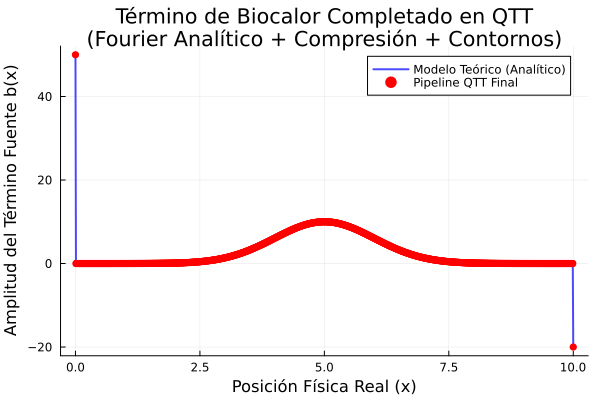

In [41]:
# 1. Configuración del dominio físico para la reconstrucción
N = 2^L
x_vals = 0:(N-1)
# Creamos la correspondencia en el espacio físico real
x_fisico = range(a, b, length=N) 
vec_b_final = zeros(Float64, N)

println("Evaluando el MPS final con contornos punto por punto...")

for x in x_vals
    # Aplicamos reverse() para mantener la consistencia del Endianness
    estado_binario = reverse(string(x, base=2, pad=L)) 
    vector_estados = [string(bit) for bit in estado_binario]
    estado_mps = MPS(sites, vector_estados)
    
    # Calculamos el producto interno y extraemos la componente real
    vec_b_final[x+1] = real(inner(estado_mps, mps_final))
end

# 2. Generación del vector teórico utilizando las posiciones físicas reales
vec_b_teorico = [Q0 * exp(-((x_f - μ)^2) / (2 * σ^2)) for x_f in x_fisico]
vec_b_teorico[1] += ΔL          # Añadimos el salto izquierdo en x = a
vec_b_teorico[end] += ΔR        # Añadimos el salto derecho en x = b

# 3. Renderizado de la Gráfica usando el eje x físico
plt_final = plot(x_fisico, vec_b_teorico, 
    label="Modelo Teórico (Analítico)", 
    linewidth=2, 
    color=:blue,
    alpha=0.7)

scatter!(plt_final, x_fisico, vec_b_final, 
    label="Pipeline QTT Final", 
    markersize=4, 
    color=:red, 
    marker=:circle,
    markerstrokewidth=0)

plot!(plt_final, 
    title="Término de Biocalor Completado en QTT\n(Fourier Analítico + Compresión + Contornos)",
    xlabel="Posición Física Real (x)",
    ylabel="Amplitud del Término Fuente b(x)",
    legend=:topright,
    grid=true)

display(plt_final)